#**💻Weekly Extreme Analysis: Frequency, Mean, and Max Intensity**

> **Updated** 19-Dec-2025 <br/>
> **Team** ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)<br/>
> **Contact** Miae Kim (miaekim@apcc21.org)
<br/>

In this notebook, you will analyze weekly averaged or accumulated climate extremes from ERA5 over East Asia. You will calculate climatological weekly extreme statistics (frequency, mean intensity, max intensity) and visualize them spatially.

NOTE: The codes for calculating extreme statistics were written to handle the limited RAM constraints of Google Colab through use of Dask chunking.

Data Directory: 2.Weekly_ERA5

## ⚙️**Requirements**

***"You can mount /content/drive/ to your Google Drive, where you will download data from the GitHub page(https://github.com/yyalexlee/EastAsiaClimateExtremes/tree/main)."***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Download data**

Create FIRST directories if needed with the following line OR by yourself.

You can change the following path.

In [ ]:
#!mkdir -p /content/drive/MyDrive/APCC/Data/

Refer to the GitHub page for downloading data.

In [2]:
!wget -O /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5.zip "https://www.dropbox.com/scl/fo/w12fdxsv89tfhphrrot1l/AD7IuKrO3LrVvkCN1hEA2c0?rlkey=67vr21cu88jt9q625lzboocao&st=yo63qu2p&dl=0"

--2025-12-19 06:41:49--  https://www.dropbox.com/scl/fo/w12fdxsv89tfhphrrot1l/AD7IuKrO3LrVvkCN1hEA2c0?rlkey=67vr21cu88jt9q625lzboocao&st=yo63qu2p&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucc41fbac2850a49eb4759b7df44.dl.dropboxusercontent.com/zip_download_get/CavO7wiCg_C2oT6NEuBKjCh4mL2QSw2CHRW3jDVuBLEOhn999fj-j0nG4HgCt-Bd9miHSRvDPDg1yEEA33NN75laRahvplVfSsJdQJWh6NyQFQ# [following]
--2025-12-19 06:41:49--  https://ucc41fbac2850a49eb4759b7df44.dl.dropboxusercontent.com/zip_download_get/CavO7wiCg_C2oT6NEuBKjCh4mL2QSw2CHRW3jDVuBLEOhn999fj-j0nG4HgCt-Bd9miHSRvDPDg1yEEA33NN75laRahvplVfSsJdQJWh6NyQFQ
Resolving ucc41fbac2850a49eb4759b7df44.dl.dropboxusercontent.com (ucc41fbac2850a49eb4759b7df44.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connecting to ucc41fbac2850a49eb475

Run the following line to unzip the data OR unzip by yourself.

In [3]:
!unzip '/content/drive/MyDrive/APCC/Data/2.Weekly_ERA5.zip' -d '/content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/'

Archive:  /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5.zip
mapname:  conversion of  failed
 extracting: /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/TP_thresholds_dataset.nc  
 extracting: /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/SST_thresholds_dataset.nc  
 extracting: /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/T2m_thresholds_dataset.nc  
 extracting: /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/ERA5_7day_rolling_TP_1940_2024.nc  
 extracting: /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/ERA5_7day_rolling_T2m_1940_2024.nc  
 extracting: /content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/ERA5_7day_rolling_SST_1940_2024.nc  


✅ Delete the zip files to save space.

## **Import libraries**

In [4]:
!pip install cartopy

In [5]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import dask
from dask.diagnostics import ProgressBar
from pathlib import Path

This is to define the min and max values of colorbar automatically.

In [6]:
def get_vmin_vmax(data, percentile_min=2, percentile_max=98):
    valid_data = data.values[~np.isnan(data.values)].flatten()
    if len(valid_data) == 0:
        print(f"Warning: No valid data found. Using data min/max instead.")
        vmin = float(np.nanmin(data.values))
        vmax = float(np.nanmax(data.values))
    else:
        vmin = float(np.percentile(valid_data, percentile_min))
        vmax = float(np.percentile(valid_data, percentile_max))
    return vmin, vmax

## **Set paths**

CHANGE the following paths if needed!

In [7]:
PATH_data = "/content/drive/MyDrive/APCC/Data/2.Weekly_ERA5/"
PATH_save_stat = "/content/drive/MyDrive/APCC/statistics/"
PATH_save_fig = "/content/drive/MyDrive/APCC/figures/"

In [8]:
Path(PATH_save_stat).mkdir(parents=True, exist_ok=True)
Path(PATH_save_fig).mkdir(parents=True, exist_ok=True)

## **Set options**

Percentile threshold for extremes, Climatology reference period, Domain of interest


In [9]:
boundary = 0.90
ref_syear, ref_eyear = 1991, 2020

lon_min, lon_max = 114, 141
lat_min, lat_max = 21, 48

## **Load pre-computed 7-Day Rolling Averages / Sums and 90th percentile threshold**

***"You CAN change the target variable BELOW."***

In [10]:
varname = 'AHT' # AHT, HR, MHW

In [11]:
if varname == 'AHT':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_T2m_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30} # Chunks!
    )
    ds = ds.sortby("lat")
    data = ds.t2m_7day
    data = data.sel(time=data.time.dt.dayofweek == 0)
    threshold_file = os.path.join(PATH_data, "T2m_thresholds_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    threshold -= 273.15
    unit = 'degC'

elif varname == 'HR':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_TP_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    ds = ds.sortby("lat")
    data = ds.tp_7day
    data = data.sel(time=data.time.dt.dayofweek == 0)
    threshold_file = os.path.join(PATH_data, "TP_thresholds_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    unit = 'mm'

elif varname == 'MHW':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_SST_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    ds = ds.sortby("lat")
    data = ds.sst_7day
    data -= - 273.15
    data = data.sel(time=data.time.dt.dayofweek == 0)
    threshold_file = os.path.join(PATH_data, "SST_thresholds_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    threshold -= 273.15
    unit = 'degC'

/tmp/ipython-input-2993890599.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


In [12]:
ds

<xarray.Dataset> Size: 90MB
Dimensions:   (time: 31041, lat: 19, lon: 19)
Coordinates:
  * time      (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-25
  * lat       (lat) float64 152B 21.0 22.5 24.0 25.5 ... 43.5 45.0 46.5 48.0
  * lon       (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    doy       (time) int64 248kB dask.array<chunksize=(180,), meta=np.ndarray>
Data variables:
    t2m_7day  (time, lat, lon) float64 90MB dask.array<chunksize=(180, 9, 10), meta=np.ndarray>

In [13]:
data

<xarray.DataArray 't2m_7day' (time: 4435, lat: 19, lon: 19)> Size: 13MB
dask.array<getitem, shape=(4435, 19, 19), dtype=float64, chunksize=(179, 9, 10), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 35kB 1940-01-01 1940-01-08 ... 2024-12-23
  * lat      (lat) float64 152B 21.0 22.5 24.0 25.5 27.0 ... 43.5 45.0 46.5 48.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    doy      (time) int64 35kB dask.array<chunksize=(179,), meta=np.ndarray>
Attributes:
    long_name:  7-day rolling mean of 2-m air temperature
    units:      degC
    window:     7

In [14]:
threshold

<xarray.DataArray 'clim_90th' (doy: 366, lat: 121, lon: 240)> Size: 85MB
array([[[-17.70564684, -17.70564684, -17.70564684, ..., -17.70564684,
         -17.70564684, -17.70564684],
        [-15.18974043, -15.0869775 , -14.9851447 , ..., -15.46221466,
         -15.37858712, -15.28105818],
        [-13.59552067, -13.34726715, -13.11576364, ..., -14.36646336,
         -14.10717643, -13.8500545 ],
        ...,
        [-22.59767238, -22.68124106, -22.76470446, ..., -22.32229919,
         -22.41406446, -22.50599278],
        [-23.06159341, -23.0960144 , -23.13028935, ..., -22.97255402,
         -22.99977962, -23.02683803],
        [-23.79531076, -23.79531076, -23.79531076, ..., -23.79531076,
         -23.79531076, -23.79531076]],

       [[-17.55207607, -17.55207607, -17.55207607, ..., -17.55207607,
         -17.55207607, -17.55207607],
        [-15.16034764, -15.17956172, -15.19019601, ..., -15.27023206,
         -15.19927673, -15.14592438],
        [-13.61240779, -13.64249595, -13.67524872, ..., -13.99298837,
         -13.82283914, -13.68638807],
...
        [-22.84339927, -22.92006814, -22.99592721, ..., -22.59080505,
         -22.67698669, -22.76039821],
        [-23.06159341, -23.0960144 , -23.13028935, ..., -22.97255402,
         -22.99977962, -23.02683803],
        [-23.74185159, -23.74185159, -23.74185159, ..., -23.74185159,
         -23.74185159, -23.74185159]],

       [[-17.55207607, -17.55207607, -17.55207607, ..., -17.55207607,
         -17.55207607, -17.55207607],
        [-15.33323124, -15.26084486, -15.19019601, ..., -15.54913112,
         -15.47651215, -15.40467791],
        [-13.56005794, -13.47475194, -13.39146271, ..., -14.09334782,
         -13.85311475, -13.70271846],
        ...,
        [-22.58879264, -22.67757743, -22.76878095, ..., -22.2976338 ,
         -22.39459294, -22.49174042],
        [-22.9589495 , -23.02164394, -23.07803083, ..., -22.83364476,
         -22.85654951, -22.8934361 ],
        [-23.74217115, -23.74217115, -23.74217115, ..., -23.74217115,
         -23.74217115, -23.74217115]]])
Coordinates:
  * doy      (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365 366
  * lat      (lat) float64 968B 90.0 88.5 87.0 85.5 ... -85.5 -87.0 -88.5 -90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Attributes:
    long_name:         Climatological 90th percentile threshold of weekly mea...
    units:             K
    reference_period:  1991-2020
    window_size:       7-days

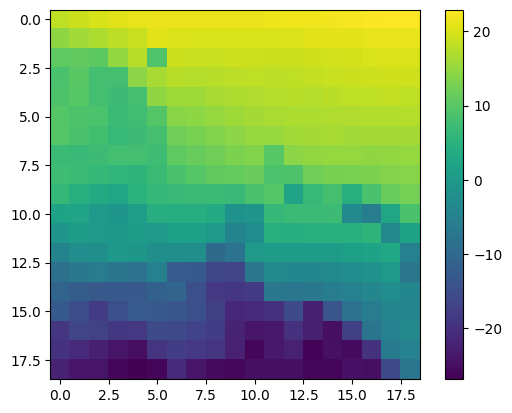

In [15]:
plt.imshow(data[0,...].values); plt.colorbar()

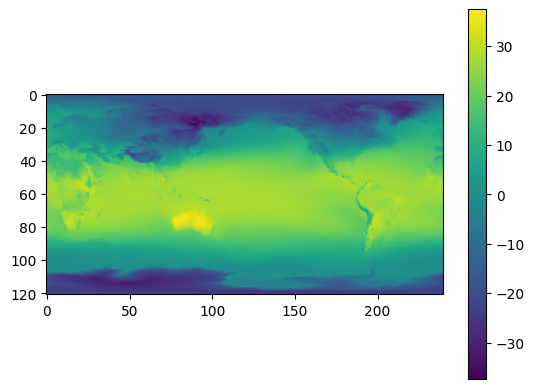

In [16]:
plt.imshow(threshold[0,...].values); plt.colorbar()

Selecting region of interest to save memory

In [17]:
print("Selecting region of interest...")
data_sel = data.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

threshold_sel = threshold.sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

print(f"Data shape after region selection: {data.shape}")

Selecting region of interest...
Data shape after region selection: (4435, 19, 19)


In [18]:
print(data_sel.shape)

(4435, 19, 19)


In [19]:
print(threshold_sel.shape)

(366, 19, 19)


In [20]:
data_sel

<xarray.DataArray 't2m_7day' (time: 4435, lat: 19, lon: 19)> Size: 13MB
dask.array<getitem, shape=(4435, 19, 19), dtype=float64, chunksize=(179, 9, 10), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 35kB 1940-01-01 1940-01-08 ... 2024-12-23
  * lat      (lat) float64 152B 21.0 22.5 24.0 25.5 27.0 ... 43.5 45.0 46.5 48.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    doy      (time) int64 35kB dask.array<chunksize=(179,), meta=np.ndarray>
Attributes:
    long_name:  7-day rolling mean of 2-m air temperature
    units:      degC
    window:     7

In [21]:
threshold_sel

<xarray.DataArray 'clim_90th' (doy: 366, lat: 19, lon: 19)> Size: 1MB
array([[[-1.46285052e+01, -1.53132124e+01, -1.60317104e+01, ...,
         -1.64779931e+01, -8.44069999e+00, -3.17315717e+00],
        [-1.44924774e+01, -1.39855541e+01, -1.47814370e+01, ...,
         -1.08675389e+01, -2.09463370e+00, -1.46179243e+00],
        [-1.57849928e+01, -1.25569837e+01, -1.33766244e+01, ...,
         -2.35800781e+00, -7.60125732e-01,  9.28227016e-02],
        ...,
        [ 1.59281145e+01,  1.68974073e+01,  1.66246403e+01, ...,
          2.24576329e+01,  2.27289167e+01,  2.29051004e+01],
        [ 1.87799617e+01,  1.87723698e+01,  1.91499220e+01, ...,
          2.36842329e+01,  2.38068695e+01,  2.38776345e+01],
        [ 2.16640324e+01,  2.24415410e+01,  2.31475978e+01, ...,
          2.48174613e+01,  2.49801065e+01,  2.48458505e+01]],

       [[-1.46009188e+01, -1.50033572e+01, -1.57187781e+01, ...,
         -1.63851321e+01, -8.87305407e+00, -3.29767674e+00],
        [-1.42949049e+01, -1.38708455e+01, -1.46674994e+01, ...,
         -1.10314806e+01, -2.32110944e+00, -1.46225412e+00],
        [-1.53707395e+01, -1.25049626e+01, -1.34725429e+01, ...,
         -2.48273664e+00, -7.33265468e-01,  6.90512521e-02],
...
        [ 1.56423763e+01,  1.64298710e+01,  1.60912907e+01, ...,
          2.24780500e+01,  2.27917712e+01,  2.29790754e+01],
        [ 1.86811271e+01,  1.86874180e+01,  1.88758650e+01, ...,
          2.37731105e+01,  2.39456791e+01,  2.41086321e+01],
        [ 2.15027832e+01,  2.21340424e+01,  2.29068359e+01, ...,
          2.49732871e+01,  2.51242065e+01,  2.51513528e+01]],

       [[-1.47343131e+01, -1.53266676e+01, -1.57820051e+01, ...,
         -1.63533425e+01, -8.39181693e+00, -3.22280753e+00],
        [-1.42949049e+01, -1.39125543e+01, -1.48433267e+01, ...,
         -1.06924713e+01, -2.21895752e+00, -1.32418387e+00],
        [-1.55071232e+01, -1.24026886e+01, -1.34566786e+01, ...,
         -2.42251848e+00, -6.35603115e-01,  2.25710188e-01],
        ...,
        [ 1.58483124e+01,  1.67233843e+01,  1.63782527e+01, ...,
          2.24200902e+01,  2.26964512e+01,  2.28534633e+01],
        [ 1.87795218e+01,  1.87681540e+01,  1.90125004e+01, ...,
          2.37118840e+01,  2.38449118e+01,  2.39289394e+01],
        [ 2.16806837e+01,  2.22849003e+01,  2.30315159e+01, ...,
          2.48929299e+01,  2.50855870e+01,  2.50034930e+01]]])
Coordinates:
  * doy      (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365 366
  * lat      (lat) float64 152B 48.0 46.5 45.0 43.5 42.0 ... 25.5 24.0 22.5 21.0
  * lon      (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
Attributes:
    long_name:         Climatological 90th percentile threshold of weekly mea...
    units:             K
    reference_period:  1991-2020
    window_size:       7-days

## **Calculate Extreme Statistics**

#### **1) Extreme Frequency per Year**

Frequency [times/yr]

Identify weeks exceeding the threshold and count extreme weeks by year.

#### **2) Mean Intensity of Extreme Weeks**

Intensity [unit/yr]

Calculate mean intensity on weeks flagged as extreme and then sum by year.

#### **3) Mean Maximum Intensity of Extreme Weeks (mm/yr)**

Max Intensity [unit/yr]

**First computing extreme mask.**

In [22]:
print("Computing extreme mask...")
doy = data['time.dayofyear']
threshold_expanded = threshold.sel(doy=doy)

extreme_mask = data >= threshold_expanded

Computing extreme mask...


Computing statistics by year for memory saving.

In [23]:
# 1. Frequency
print("  - Computing frequency...")
extreme_counts = extreme_mask.groupby('time.year').sum(dim='time')

with ProgressBar():
    extreme_counts_avg = extreme_counts.mean(dim='year').compute()

  - Computing frequency...
[########################################] | 100% Completed | 67.26 s


In [24]:
# 2. Mean Intensity
print("  - Computing mean intensity...")
extreme = data.where(extreme_mask)
extreme_avg = extreme.groupby('time.year').mean(dim='time')

with ProgressBar():
    extreme_avg_avg = extreme_avg.mean(dim='year').compute()

  - Computing mean intensity...
[########################################] | 100% Completed | 62.41 s


In [25]:
# 3. Max Intensity
print("  - Computing max intensity...")
extreme = data.where(extreme_mask)
extreme_max = extreme.groupby('time.year').max(dim='time')

with ProgressBar():
    extreme_max_avg = extreme_max.mean(dim='year').compute()

print("All statistics computed!")

  - Computing max intensity...
[########################################] | 100% Completed | 62.60 s
All statistics computed!


## **Display individual plots**

For colorbar

In [26]:
freq_vmin, freq_vmax = get_vmin_vmax(extreme_counts_avg, percentile_min=2, percentile_max=98)
intensity_vmin, intensity_vmax = get_vmin_vmax(extreme_avg_avg, percentile_min=2, percentile_max=98)
max_intensity_vmin, max_intensity_vmax = get_vmin_vmax(extreme_max_avg, percentile_min=2, percentile_max=98)

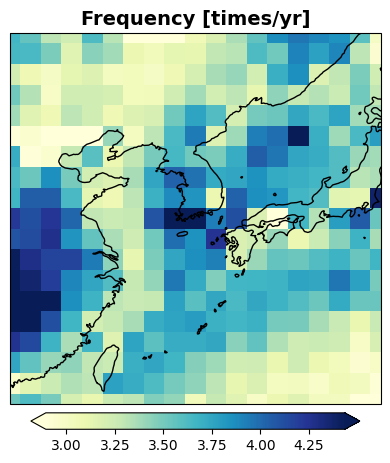

In [27]:
# Individual plots
fig = plt.figure(figsize=(5,5))
ax  = plt.axes(projection=ccrs.PlateCarree())
im  = extreme_counts_avg.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlGnBu',
                vmin=freq_vmin, vmax=freq_vmax,
                cbar_kwargs={"shrink":0.7, 'pad':0.02, 'location':'bottom'})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title("Frequency [times/yr]", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

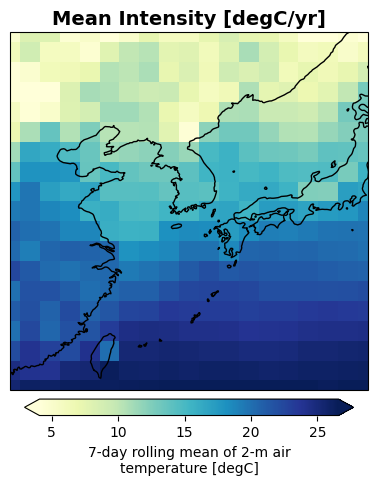

In [28]:
fig = plt.figure(figsize=(5,5))
ax  = plt.axes(projection=ccrs.PlateCarree())
im  = extreme_avg_avg.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlGnBu',
                vmin=intensity_vmin,
                vmax=intensity_vmax,
                cbar_kwargs={"shrink":0.7, 'pad':0.02, 'location':'bottom'})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title(f"Mean Intensity [{unit}/yr]", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

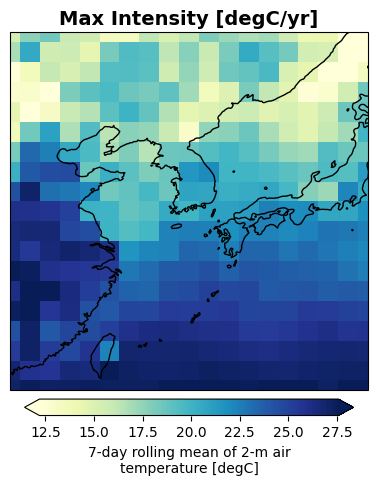

In [29]:
fig = plt.figure(figsize=(5,5))
ax  = plt.axes(projection=ccrs.PlateCarree())
im  = extreme_max_avg.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlGnBu',
                vmin=max_intensity_vmin,
                vmax=max_intensity_vmax,
                cbar_kwargs={"shrink":0.7, 'pad':0.02, 'location':'bottom'})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title(f"Max Intensity [{unit}/yr]", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

## **Combined Visualization & Save Figure**

In [30]:
# ====== Plot together
plot_info = [
    (extreme_counts_avg, "Frequency [times/yr]", freq_vmin, freq_vmax, "YlGnBu"),
    (extreme_avg_avg, f"Mean Intensity [{unit}/yr]", intensity_vmin, intensity_vmax, "YlGnBu"),
    (extreme_max_avg, f"Max Intensity [{unit}/yr]", max_intensity_vmin, max_intensity_vmax, "YlGnBu"),
]

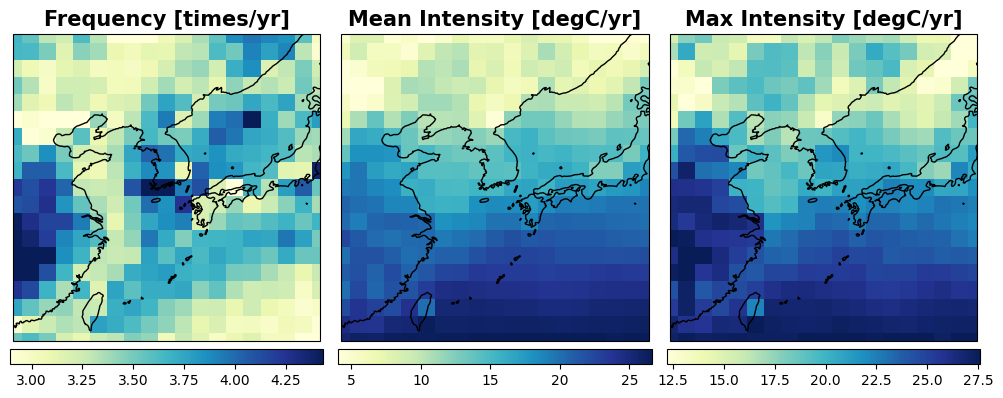

In [31]:
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(10, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, (data_plot, title, vmin, vmax, cmap) in zip(axes, plot_info):
    im = data_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=15, fontweight="bold")
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.02,
    )

plt.tight_layout()
plt.savefig(os.path.join(PATH_save_fig, f"{varname}_extreme_weeks_statistics_maps.png"),
            dpi=100, bbox_inches='tight')
plt.show()
plt.close()

## **Save statistics (NetCDF)**

Prepare dataset with frequency, mean intensity, and max intensity including metadata.


In [32]:
# === Save statistics (NetCDF)
ds_extremes = xr.Dataset(
    {
        "frequency": extreme_counts_avg,
        "mean_intensity": extreme_avg_avg,
        "mean_max_intensity": extreme_max_avg,
    }
)
# Metadata
ds_extremes.frequency.attrs["units"] = "times/year"
ds_extremes.mean_intensity.attrs["units"] = f"{unit}/year"
ds_extremes.mean_max_intensity.attrs["units"] = f"{unit}/year"
ds_extremes.attrs["reference_period"] = f"{ref_syear}-{ref_eyear}"

In [33]:
# Save as NetCDF
out_path = os.path.join(PATH_save_stat,
                        f"{varname}_extreme_stats_{ref_syear}_{ref_eyear}_p{int(boundary*100)}.nc")
ds_extremes.to_netcdf(out_path)
print(f"Saved combined dataset to {out_path}")

Saved combined dataset to /content/drive/MyDrive/APCC/statistics/AHT_extreme_stats_1991_2020_p90.nc
